In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import re
import os

In [2]:
df = pd.read_csv(r'D:\IT\Python\sklearn\hotel-booking-project\data\hotel_bookings.csv')
pd.set_option('display.max_columns', None)

In [3]:
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [4]:
pd.crosstab(df["hotel"], df["is_canceled"])

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


<Axes: xlabel='is_canceled'>

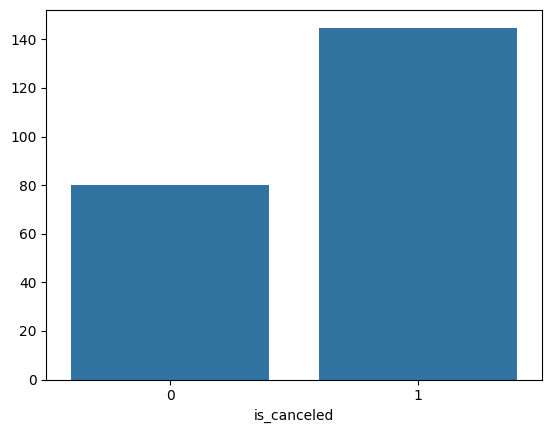

In [5]:
lead = df.groupby('is_canceled')['lead_time'].mean()
sns.barplot(x=lead.index, y=lead.values)

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

In [7]:
num_cols = [
    "lead_time",
    "adr",
    "booking_changes",
    "days_in_waiting_list"
]

In [16]:
cc = df.groupby("is_canceled")
a = cc['adr'].mean()
b = cc['booking_changes'].mean()
c = cc['days_in_waiting_list'].mean()
d = cc['lead_time'].mean()

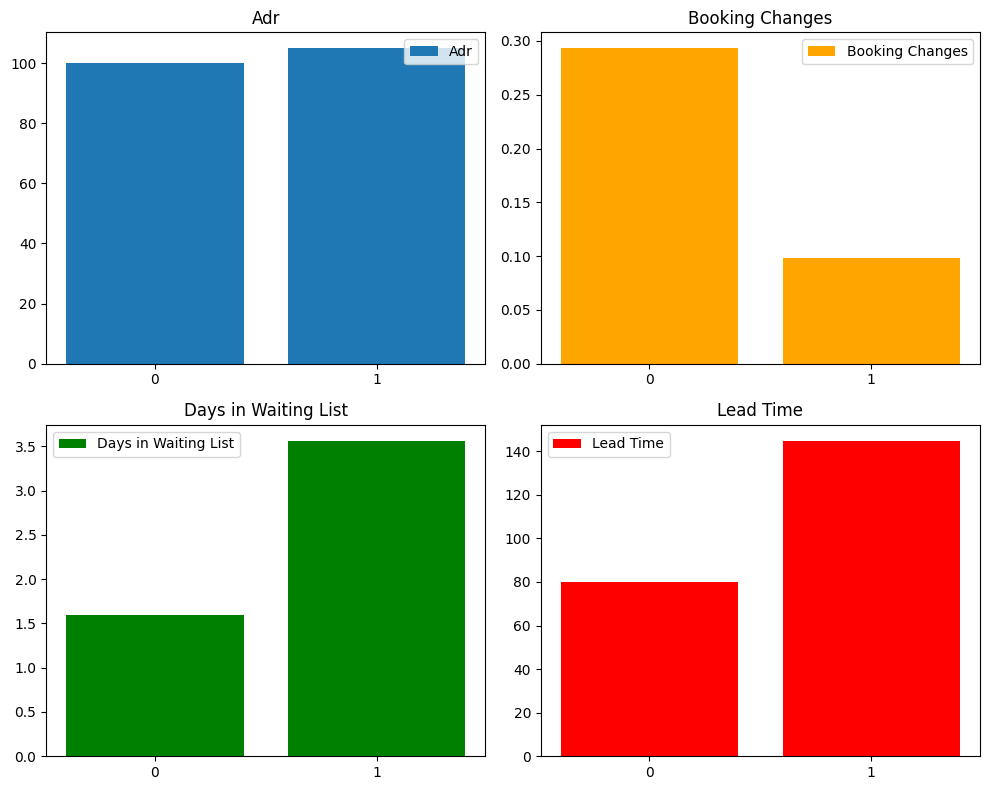

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax1, ax2, ax3, ax4 = axes.flatten()
ax1.bar(a.index, a.values, label="Adr")
ax1.set_xticks([0, 1])
ax1.set_title("Adr")
ax1.legend()

ax2.bar(b.index, b.values, label="Booking Changes", color='orange')
ax2.set_xticks([0, 1])
ax2.set_title("Booking Changes")
ax2.legend()

ax3.bar(c.index, c.values, label="Days in Waiting List", color='green')
ax3.set_xticks([0, 1])
ax3.set_title("Days in Waiting List")
ax3.legend()

ax4.bar(d.index, d.values, label="Lead Time", color='red')
ax4.set_xticks([0, 1])
ax4.set_title("Lead Time")
ax4.legend()
plt.tight_layout()

In [9]:
p = df.groupby('country')['is_canceled'].mean().sort_values(ascending=False).head(20)

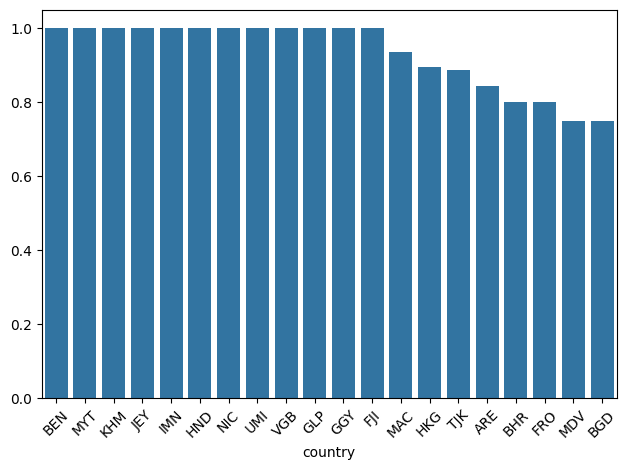

In [10]:
sns.barplot(x = p.index, y = p.values)
plt.xticks(rotation=45)
plt.tight_layout()

In [11]:
pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
deposit_type,,
No Deposit,0.716230,0.283770
Non Refund,0.006376,0.993624
Refundable,0.777778,0.222222


In [12]:
pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
market_segment,,
Aviation,0.780591,0.219409
Complementary,0.869448,0.130552
Corporate,0.812653,0.187347
Direct,0.846581,0.153419
Groups,0.389380,0.610620
Offline TA/TO,0.656840,0.343160
Online TA,0.632789,0.367211
Undefined,0.000000,1.000000


In [13]:
pd.crosstab(
    df["customer_type"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
customer_type,,
Contract,0.690383,0.309617
Group,0.897747,0.102253
Transient,0.592537,0.407463
Transient-Party,0.745701,0.254299


In [14]:
pd.crosstab(
    df["distribution_channel"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
distribution_channel,,
Corporate,0.779242,0.220758
Direct,0.825401,0.174599
GDS,0.808290,0.191710
TA/TO,0.589741,0.410259
Undefined,0.200000,0.800000


In [26]:
pd.crosstab(
    df["arrival_date_month"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
arrival_date_month,,
April,0.592028,0.407972
August,0.622469,0.377531
December,0.650295,0.349705
February,0.665840,0.334160
January,0.695227,0.304773
July,0.625464,0.374536
June,0.585428,0.414572
March,0.678477,0.321523
May,0.603342,0.396658


In [27]:
pd.crosstab(
    df['adults'],
    df['is_canceled'],
    normalize='index')

is_canceled,0,1
adults,,
0,0.729529,0.270471
1,0.710166,0.289834
2,0.606847,0.393153
3,0.653176,0.346824
4,0.741935,0.258065
5,0.000000,1.000000
6,0.000000,1.000000
10,0.000000,1.000000
20,0.000000,1.000000


In [29]:
pd.crosstab(
    df['is_repeated_guest'],
    df['is_canceled'],
    normalize='index')

is_canceled,0,1
is_repeated_guest,,
0,0.622149,0.377851
1,0.855118,0.144882


In [30]:
pd.crosstab(
    df['babies'],
    df['is_canceled'],
    normalize='index')

is_canceled,0,1
babies,,
0,0.628126,0.371874
1,0.816667,0.183333
2,0.866667,0.133333
9,1.000000,0.000000
10,1.000000,0.000000


In [31]:
pd.crosstab(
    df['children'],
    df['is_canceled'],
    normalize='index')

is_canceled,0,1
children,,
0.0,0.629102,0.370898
1.0,0.677638,0.322362
2.0,0.578039,0.421961
3.0,0.776316,0.223684
10.0,0.000000,1.000000


In [32]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

Text(0.5, 1.0, 'Days in waiting list')

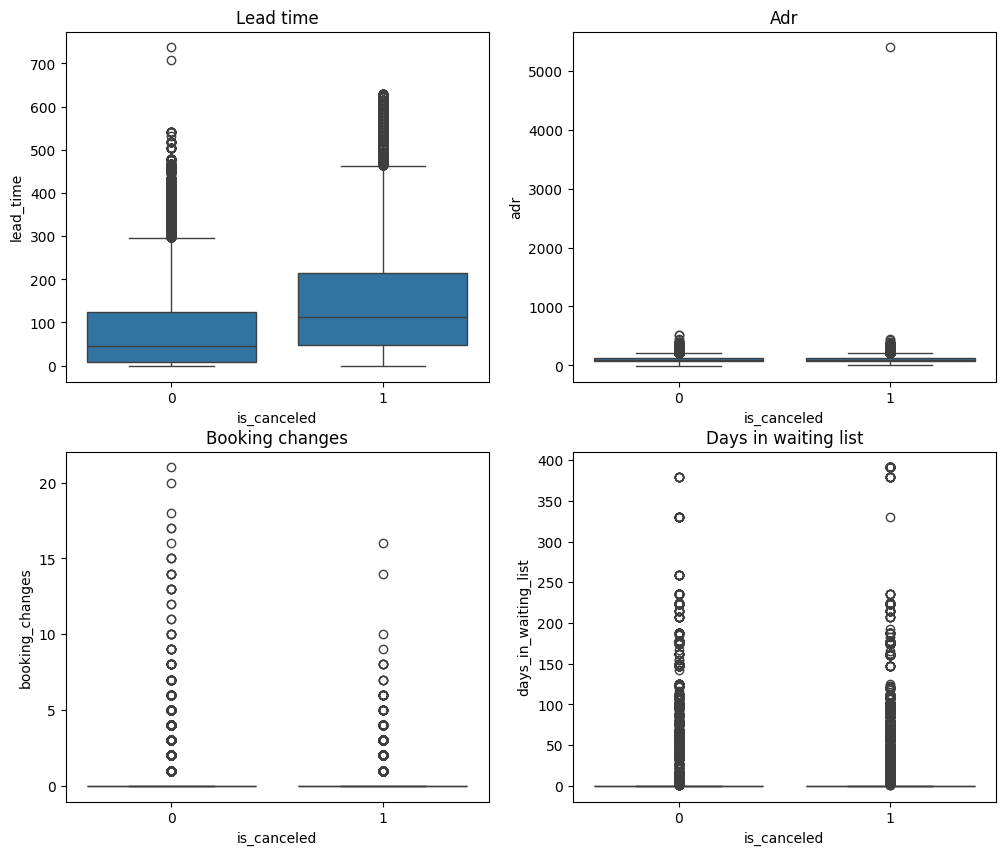

In [39]:
fig, axes = plt.subplots(2, 2, figsize = (12,10))
ax1, ax2, ax3, ax4, = axes.flatten()
sns.boxplot(data=df, x='is_canceled', y='lead_time', ax=ax1)
ax1.set_title("Lead time")
sns.boxplot(data=df, x='is_canceled', y='adr', ax=ax2)
ax2.set_title("Adr")
sns.boxplot(data=df, x='is_canceled', y='booking_changes', ax=ax3)
ax3.set_title("Booking changes")
sns.boxplot(data=df, x='is_canceled', y='days_in_waiting_list', ax=ax4)
ax4.set_title("Days in waiting list")